# BANK LOAN ANALYSIS REPORT


### IMPORT LIBRARIES



In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [44]:
df = pd.read_excel("C:/Users/maya1/Downloads/financial_loan_data_excel.xlsx")

In [45]:
df.head()


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


# MetaData of Data


In [46]:
print("no_of_rows:",df.shape[0])

no_of_rows: 38576


In [47]:
print("no_of_columns:",df.shape[1])

no_of_columns: 24


In [48]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

## Data Types

In [49]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [50]:
df.describe


<bound method NDFrame.describe of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat

## Total Loan Application

In [51]:
total_loan_application = df['id'].count()
print("Total Loan Applications:",total_loan_application)

Total Loan Applications: 38576


## MTD Total Loan Application

In [52]:
latest_issue_date = df['issue_date'].max()

latest_year = latest_issue_date.year 
latest_month =  latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications(for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

MTD Loan Applications(for December 2021): 4314


##  Total Funded Amount

In [53]:
total_funded_amount = df['id'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total funded amount:${:.2f}M".format(total_funded_amount_millions))

Total funded amount:$26271.69M


## MTD Total Funded Amount

In [54]:
latest_issue_date =  df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/1000000 

print("MTD Total Funded Amount:${:.2f}M".format( mtd_total_funded_amount_millions))

MTD Total Funded Amount:$53.98M


## Total Amount Recieved

In [55]:
total_amount_recieved = df['id'].sum()
total_amount_recieved_millions = total_amount_recieved/1000000
print("Total amount recieved:${:.2f}M".format(total_amount_recieved_millions))

Total amount recieved:$26271.69M


## MTD Total Amount Recieved


In [56]:
latest_issue_date =  df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_total_amount_recieved = mtd_data['total_payment'].sum()
mtd_total_amount_recieved_millions = mtd_total_funded_amount/1000000 

print("MTD total_amount_recieved:${:.2f}M".format(mtd_total_amount_recieved_millions))

MTD total_amount_recieved:$53.98M


## Average Interest Rate


In [57]:
average_interest_rate= df['int_rate'].mean()*100
print("Avg Int Rate: {:.2f}%".format(average_interest_rate))

Avg Int Rate: 12.05%


## Average Debt-to-Income Ratio (DTI)

In [58]:
average_dti= df['dti'].mean()*100
print("Avg DTI:{:.2f}%".format(average_dti))

Avg DTI:13.33%


## Good Loan Metrics

In [59]:
good_loans= df [df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()

good_loan_funded_amount = good_loans['loan_amount'].sum()

good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)

print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))

print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))

print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


## Bad Loan Metrics

In [60]:
bad_loans= df [df['loan_status'].isin(["Charged Off"])] #Bad Loans

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()

bad_loan_funded_amount = bad_loans['loan_amount'].sum()

bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_millions = bad_loan_received / 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", good_loan_applications)

print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))

print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))

print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 33243
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


## Monthly Trends by Issue Date for Total  Amount Recieved

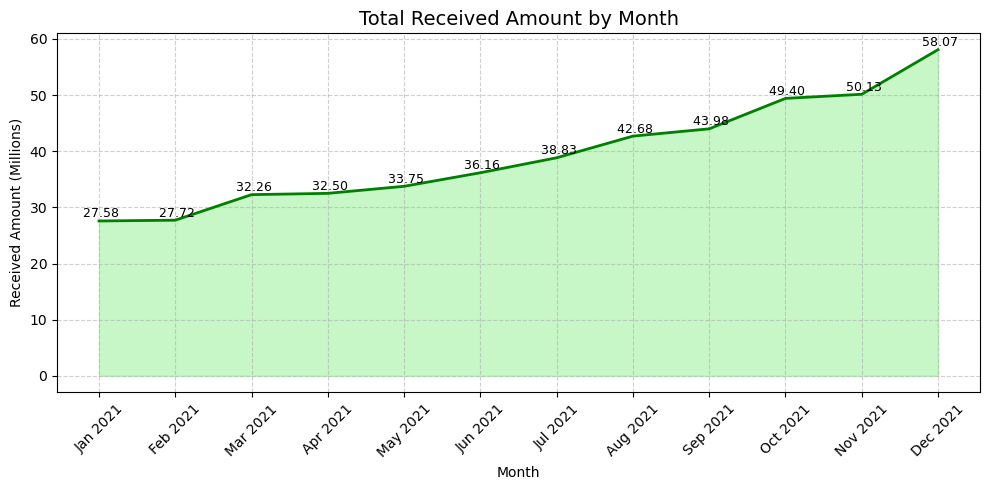

In [61]:
monthly_received = (

df.sort_values('issue_date')

.assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))

.groupby('month_name', sort=False)['total_payment']

.sum()

.div(1000000)

.reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between (monthly_received['month_name'], monthly_received['received_amount_millions'],
color = 'lightgreen', alpha=0.5)
plt.plot(monthly_received['month_name'], monthly_received['received_amount_millions'], color='green', linewidth=2)

for i, row in monthly_received.iterrows():
   plt.text(i, row['received_amount_millions'] + 0.1, f" {row['received_amount_millions']:.2f}",
    ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)

plt.xlabel('Month')

plt.ylabel('Received Amount (Millions)')

plt.xticks(ticks=range(len(monthly_received)), labels= monthly_received['month_name'], rotation=45)

plt.grid(True, linestyle= '--', alpha=0.6)

plt.tight_layout()

plt.show()

## Monthly Trends by Issue Date for Total Loan Applications

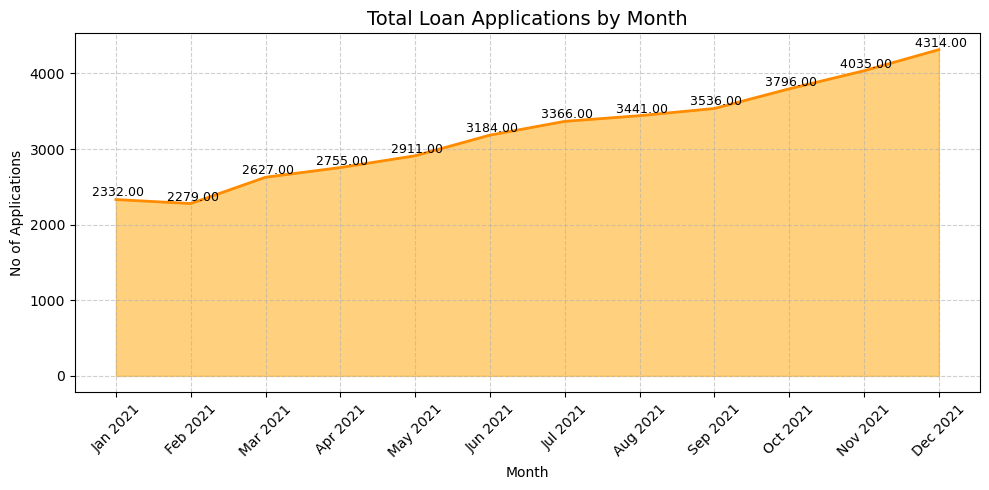

In [62]:
monthly_applications = (

df.sort_values('issue_date')
.assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
.groupby('month_name', sort=False)['id']
.count()
.reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))
plt.fill_between (monthly_applications['month_name'], monthly_applications['loan_applications_count'],
color = 'orange', alpha=0.5)
plt.plot(monthly_applications['month_name'], monthly_applications['loan_applications_count'],
         color='darkorange', linewidth=2)

for i, row in monthly_applications.iterrows():
   plt.text(i, row['loan_applications_count'] + 0.5, f" {row['loan_applications_count']:.2f}",
    ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Loan Applications by Month', fontsize=14)

plt.xlabel('Month')

plt.ylabel('No of Applications')

plt.xticks(ticks=range(len(monthly_applications)), labels= monthly_applications['month_name'], rotation=45)

plt.grid(True, linestyle= '--', alpha=0.6)

plt.tight_layout()

plt.show()

## Monthly Trends by Issue Date for Total Amount Funded

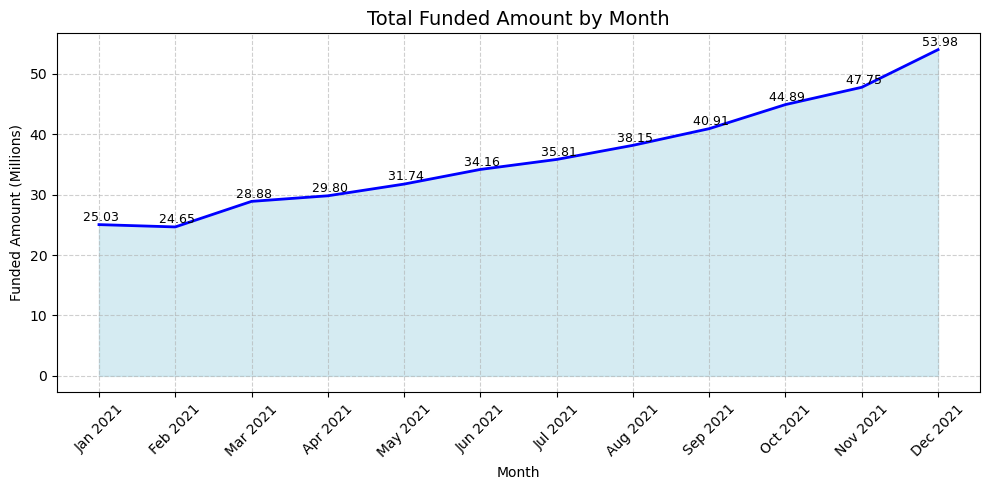

In [63]:
monthly_funded = (

df.sort_values('issue_date')

.assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))

.groupby('month_name', sort=False)['loan_amount']

.sum()

.div(1000000)

.reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between (monthly_funded['month_name'], monthly_funded['loan_amount_millions'],
color = 'lightblue', alpha=0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='blue', linewidth=2)

for i, row in monthly_funded.iterrows():
   plt.text(i, row['loan_amount_millions'] + 0.1, f" {row['loan_amount_millions']:.2f}",
    ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Funded Amount by Month', fontsize=14)

plt.xlabel('Month')

plt.ylabel('Funded Amount (Millions)')

plt.xticks(ticks=range(len(monthly_received)), labels= monthly_received['month_name'], rotation=45)

plt.grid(True, linestyle= '--', alpha=0.6)

plt.tight_layout()

plt.show()

## Regional Analysis by State for Total Funded Amount


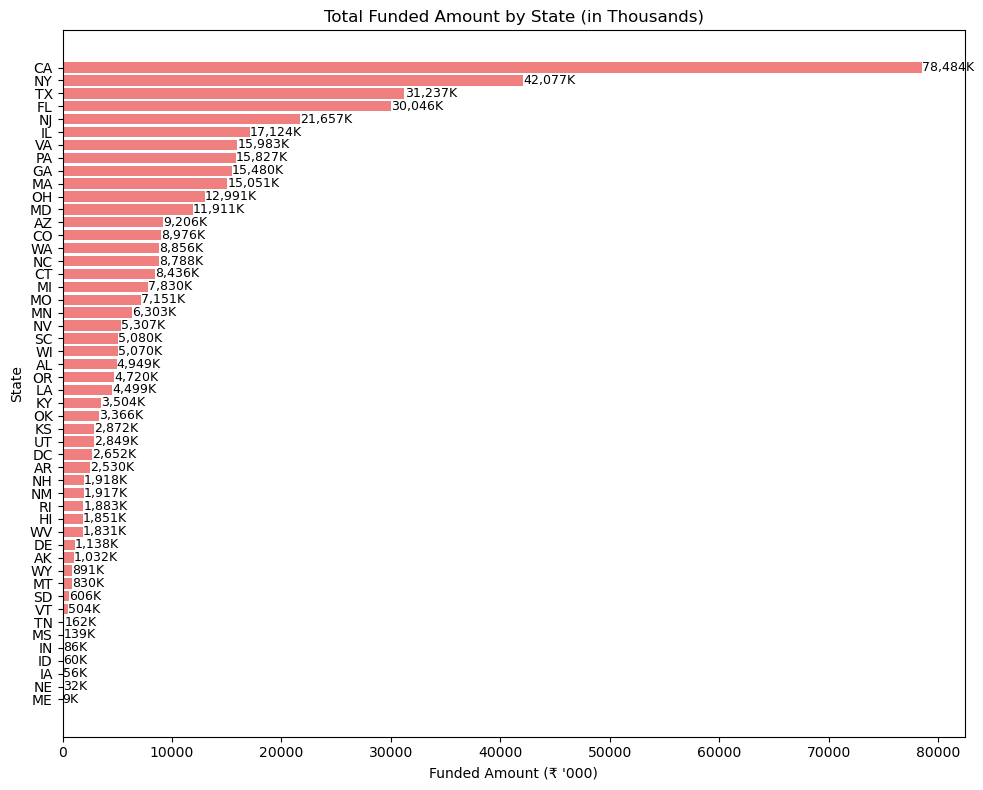

In [67]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True) 
state_funding_thousands = state_funding / 1000

plt.figure(figsize = (10, 8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'lightcoral')

for bar in bars:
         width = bar.get_width()
         plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
         f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in Thousands)')
plt.xlabel('Funded Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Loan Term Analysis by Total Funded Amount

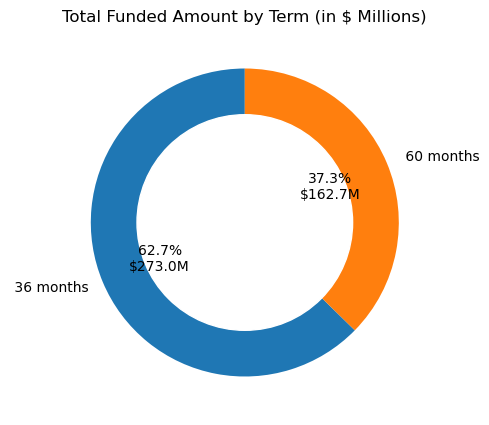

In [71]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5, 5))

plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct= lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white')) 
plt.title("Total Funded Amount by Term (in $ Millions)")

plt.show()

## Employee Length by Total Funded Amount

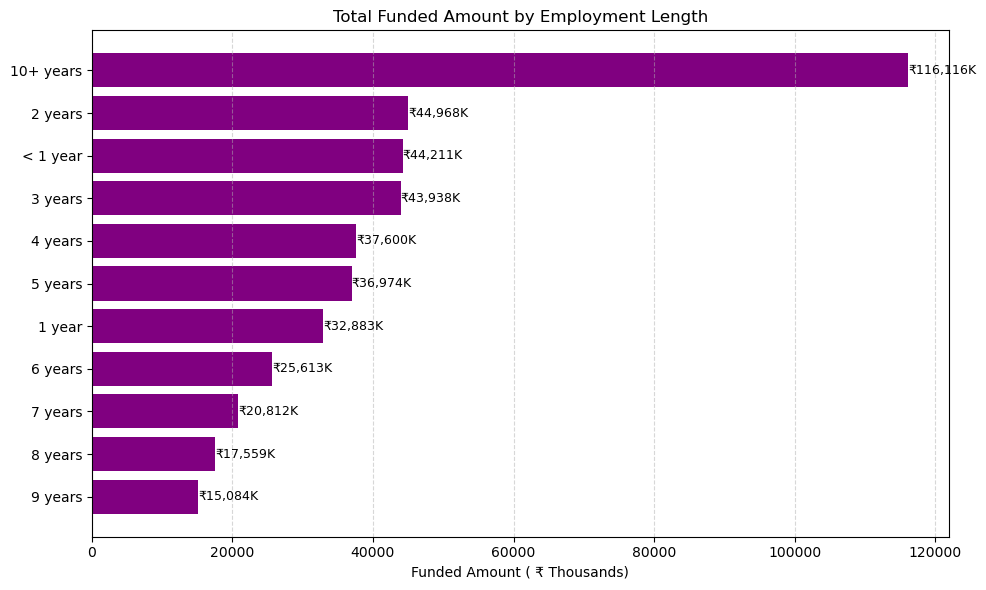

In [82]:
emp_funding_thousands = df.groupby('emp_length') ['loan_amount'].sum().sort_values()/1000


plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

for bar in bars:
    width= bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2, 
             f"₹{width:,.0f}K", va='center', fontsize=9)

plt.xlabel("Funded Amount ( ₹ Thousands)")

plt.title("Total Funded Amount by Employment Length")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()


## Loan Purpose by Total Funded Amount

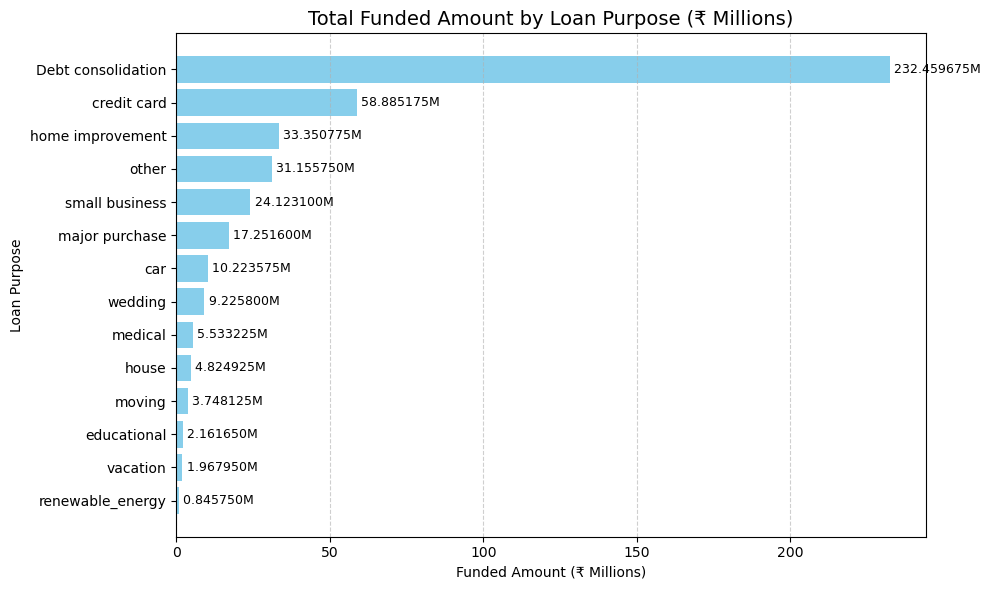

In [88]:
purpose_funding_millions = (df.groupby('purpose') ['loan_amount'].sum().sort_values()/1000000)

plt.figure(figsize=(10, 6)) 

bars =  plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')

for bar in bars:
    width=  bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
       f'{width: 2f}M', va='center', fontsize=9)

plt.title('Total Funded Amount by Loan Purpose (₹ Millions)', fontsize=14)

plt.xlabel('Funded Amount (₹ Millions)')

plt.ylabel('Loan Purpose')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

## Home Ownership by Total Funded Amount

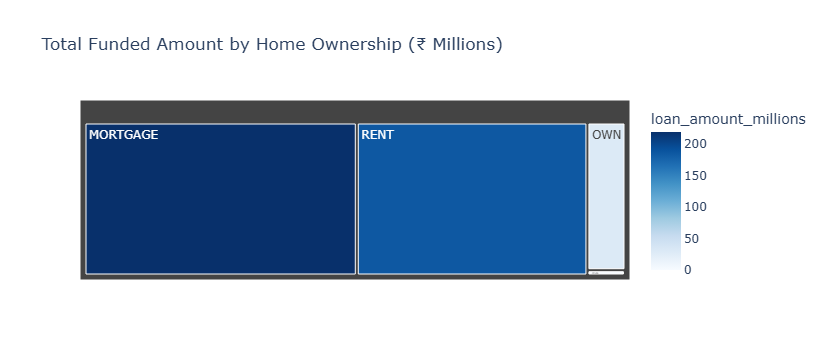

In [89]:
home_funding = df.groupby('home_ownership') ['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
   home_funding,
  path= ['home_ownership'],
  values='loan_amount_millions',
  color='loan_amount_millions',
  color_continuous_scale='Blues',
  title='Total Funded Amount by Home Ownership (₹ Millions)'
)
fig.show()